## Circuito Ponte Wheatstone

Bibliotecas:

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

Constantes do experimento:

In [7]:
R2 = 91.7 # Ohms
R3 = 4.6 # Ohms
R4 = 91.5 # Ohms
RG = 12.2 # Ohms
V0 = 1.626 # Volts

Dados experimentais:

In [8]:
R1_exp = [1.8, 2.1, 2.3, 2.5, 2.7, 2.9, 3.1, 3.3, 3.3, 3.3, 3.4, 3.6, 3.8, 4, 4.1, 4.2, 4.4, 4.5, 4.8, 4.8, 5.1, 5.2, 5.2, 5.4] # Ohms
R1_exp = [r - 0.3 for r in R1_exp]
Vab_exp = [-27.5, -26.9, -23, -21, -19.7, -19.5, -17.8, -15.6, -14.8, -13.4, -12, -10.5, -8.1, -7.9, -7.1, -5.7, -4.6, -3.8, -2, 0.08, 0.08, 2.1, 3.5, 4.3] # mV

Solução analítica:

R² = 0.9876


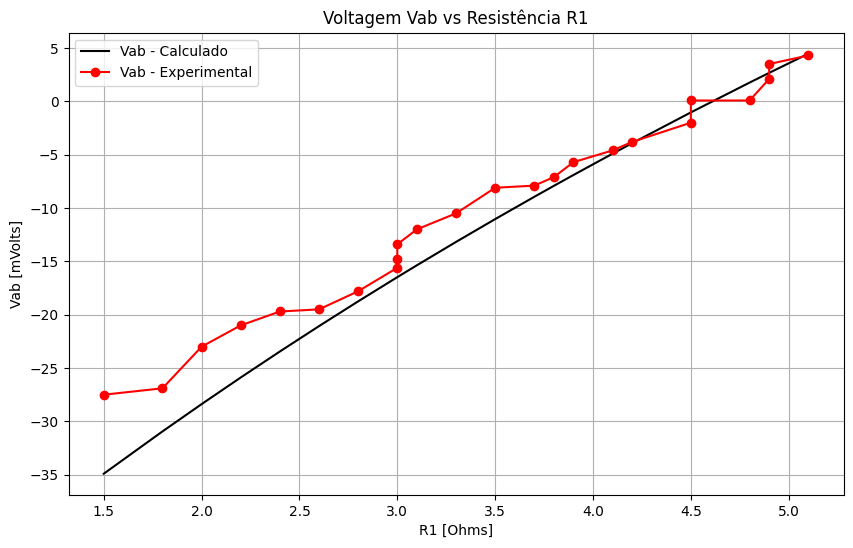

In [9]:
def Va(a, b, c, d, R1):
    return (a*(R1-b))/(c*R1+d)

def coefs(R2, R3, R4, RG, V0):
    a = (R4*V0)
    b = (R2*R3)/R4
    c = R3+R4+(((R3*R4)+(R2*R4)+(R3*R2))/RG)
    d = (R2*(R3+R4))+((R3*R2*R4)/RG)
    return a, b, c, d

a, b, c, d = coefs(R2, R3, R4, RG, V0)
Vab_ideal = [Va(a, b, c, d, r)*1e3 for r in R1_exp]

# Ajuste linear entre Vab_ideal (calculado) e Vab_exp (experimental)
slope, intercept, r_value, p_value, std_err = linregress(Vab_ideal, Vab_exp)
print(f"R² = {r_value**2:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(R1_exp, Vab_ideal, label='Vab - Calculado', color='black')
plt.plot(R1_exp, Vab_exp, 'o-', label='Vab - Experimental', color='red')
plt.xlabel('R1 [Ohms]')
plt.ylabel('Vab [mVolts]')
plt.title('Voltagem Vab vs Resistência R1')
plt.legend()
plt.grid()
plt.show()

Solução nodal:

R² = 0.9876


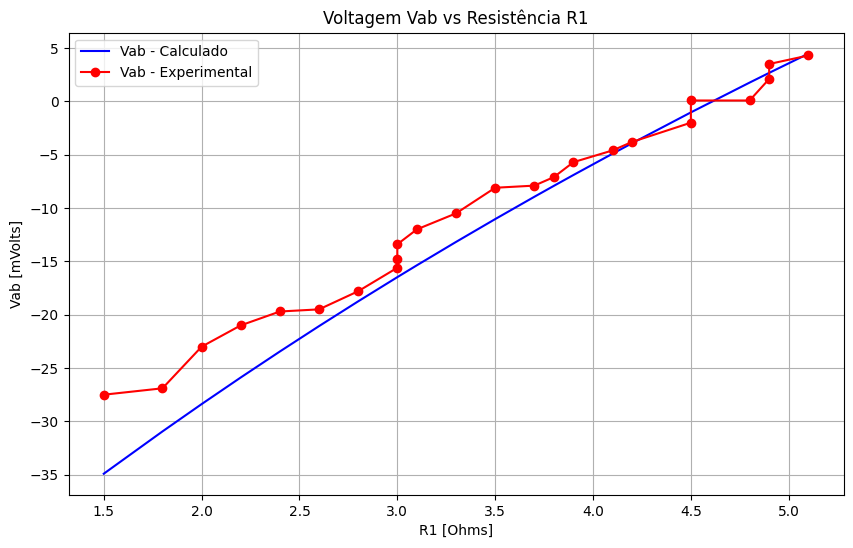

In [10]:
def solve(R1, R2, R3, R4, RG, V0):
    alpha = ((1/R1)+(1/RG)+(1/R2))
    beta = -(1/RG)
    gamma = ((1/R3)+(1/RG)+(1/R4))

    A = np.array([[alpha, beta], [beta, gamma]])
    B = np.array([V0*(1/R1), V0*(1/R3)])

    X = np.linalg.solve(A, B)

    return X

X = [solve(R1, R2, R3, R4, RG, V0) for R1 in R1_exp]

V_a, V_b = zip(*X)

Vab = [(V_b[i] - V_a[i])*1e3 for i in range(len(V_a))]

slope, intercept, r_value, p_value, std_err = linregress(Vab, Vab_exp)
print(f"R² = {r_value**2:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(R1_exp, Vab, label='Vab - Calculado', color='blue')
plt.plot(R1_exp, Vab_exp, 'o-', label='Vab - Experimental', color='red')
plt.xlabel('R1 [Ohms]')
plt.ylabel('Vab [mVolts]')
plt.title('Voltagem Vab vs Resistência R1')
plt.legend()
plt.grid()
plt.show()